# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Bedtime Screentime Dataset](https://www.kaggle.com/datasets/samartalwar/sleep-debt-and-screen-time-late-night-phone-habits)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/samartalwar/sleep-debt-and-screen-time-late-night-phone-habits/bedtime_screentime_sleep_debt.csv


## Import CSV And convert to DataFrame

In [18]:
df = pd.read_csv('bedtime_screentime_sleep_debt.csv')

# Preprocessing

## Frist five row

In [19]:
df.head()

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt


## last Five row

In [20]:
df.tail()

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
8495,USR-08496,61,Female,Remote Tech,Night Owl,18,Streaming (Netflix/Hulu),61,1,60,74,21.0,5.57,26.5,18.1,3,3.2,Moderate Debt
8496,USR-08497,64,Male,Student,Night Owl,138,TikTok / Reels,58,1,0,58,84.3,3.99,20.4,19.4,7,10.0,Severe Sleep Debt
8497,USR-08498,34,Male,Corporate 9-to-5,Intermediate,56,Streaming (Netflix/Hulu),56,0,94,33,40.6,7.58,17.4,20.7,2,3.7,Mild Deficit
8498,USR-08499,23,Male,Healthcare / Shift Worker,Night Owl,165,TikTok / Reels,72,0,0,52,123.3,3.20,14.2,15.8,7,10.0,Severe Sleep Debt
8499,USR-08500,27,Female,Student,Night Owl,108,Instagram / Reddit,35,1,0,23,55.7,4.04,27.3,18.7,5,6.7,Moderate Debt


## Shape of our dataset

In [21]:
df.shape

(8500, 18)

## List out all columns

In [22]:
df.columns

Index(['user_id', 'age', 'gender', 'occupation_type', 'chronotype',
       'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct',
       'blue_light_filter_active', 'caffeine_post_5pm_mg',
       'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours',
       'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes',
       'next_day_fatigue_score', 'sleep_debt_category'],
      dtype='object')

## Datatype of each columns

In [23]:
df.dtypes

user_id                      object
age                           int64
gender                       object
occupation_type              object
chronotype                   object
bedtime_phone_minutes         int64
primary_bedtime_app          object
screen_brightness_pct         int64
blue_light_filter_active      int64
caffeine_post_5pm_mg          int64
physical_activity_min         int64
sleep_latency_min           float64
total_sleep_hours           float64
deep_sleep_pct              float64
rem_sleep_pct               float64
morning_alarm_snoozes         int64
next_day_fatigue_score      float64
sleep_debt_category          object
dtype: object

## Information of all Columns

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   object 
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   object 
 3   occupation_type           8500 non-null   object 
 4   chronotype                8500 non-null   object 
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   object 
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_slee

## Check Null Value

In [25]:
df.isnull().sum()

user_id                     0
age                         0
gender                      0
occupation_type             0
chronotype                  0
bedtime_phone_minutes       0
primary_bedtime_app         0
screen_brightness_pct       0
blue_light_filter_active    0
caffeine_post_5pm_mg        0
physical_activity_min       0
sleep_latency_min           0
total_sleep_hours           0
deep_sleep_pct              0
rem_sleep_pct               0
morning_alarm_snoozes       0
next_day_fatigue_score      0
sleep_debt_category         0
dtype: int64

## Check Dupicate Value

In [26]:
df.duplicated().sum()

np.int64(0)

## Summary

In [27]:
df.describe()

,age,bedtime_phone_minutes,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score
count,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000
mean,34.355647,59.250000,55.153882,0.467765,33.222471,35.701412,40.671471,6.266209,21.735741,19.105859,2.766000,3.794671
std,11.584259,36.931991,19.850550,0.498989,51.935645,20.819390,17.444914,1.446258,3.069377,2.546459,1.695407,2.685153
min,18.000000,1.000000,10.000000,0.000000,0.000000,0.000000,6.000000,3.200000,8.100000,9.600000,0.000000,1.000000
25%,25.000000,31.000000,42.000000,0.000000,0.000000,21.000000,28.200000,5.240000,19.700000,17.400000,2.000000,1.100000
50%,32.000000,51.000000,55.000000,0.000000,0.000000,35.000000,37.600000,6.330000,21.900000,19.100000,3.000000,3.200000
75%,42.000000,79.000000,69.000000,1.000000,55.000000,50.000000,49.700000,7.350000,23.900000,20.800000,4.000000,5.600000
max,65.000000,180.000000,100.000000,1.000000,250.000000,112.000000,123.300000,9.800000,28.000000,27.000000,7.000000,10.000000


# EDA

In [28]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

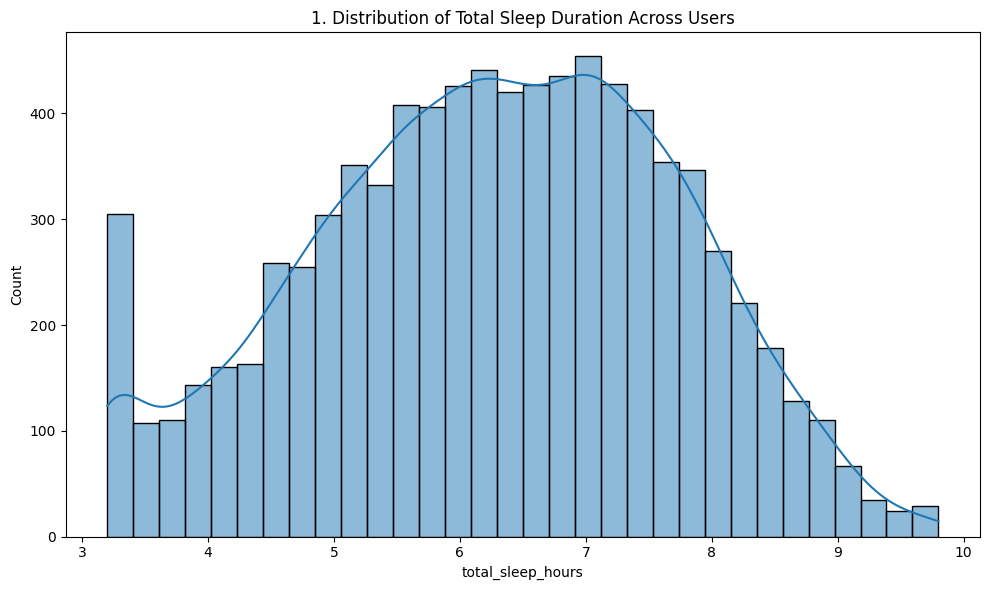

In [29]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='total_sleep_hours', kde=True)
plt.title(f'{plot_no}. Distribution of Total Sleep Duration Across Users')
show_fig()
plot_no += 1

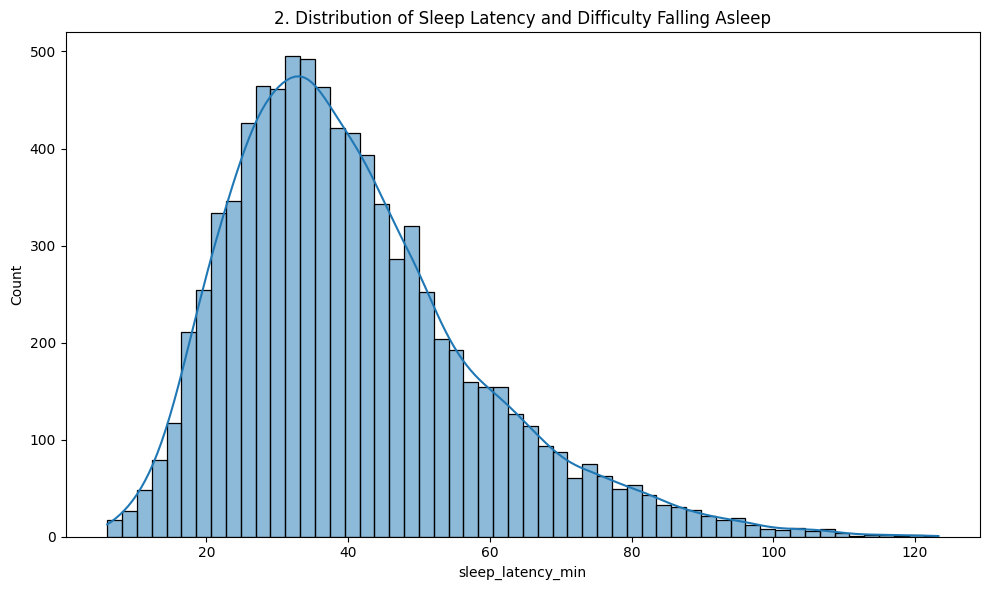

In [30]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='sleep_latency_min', kde=True)
plt.title(f'{plot_no}. Distribution of Sleep Latency and Difficulty Falling Asleep')
show_fig()
plot_no += 1

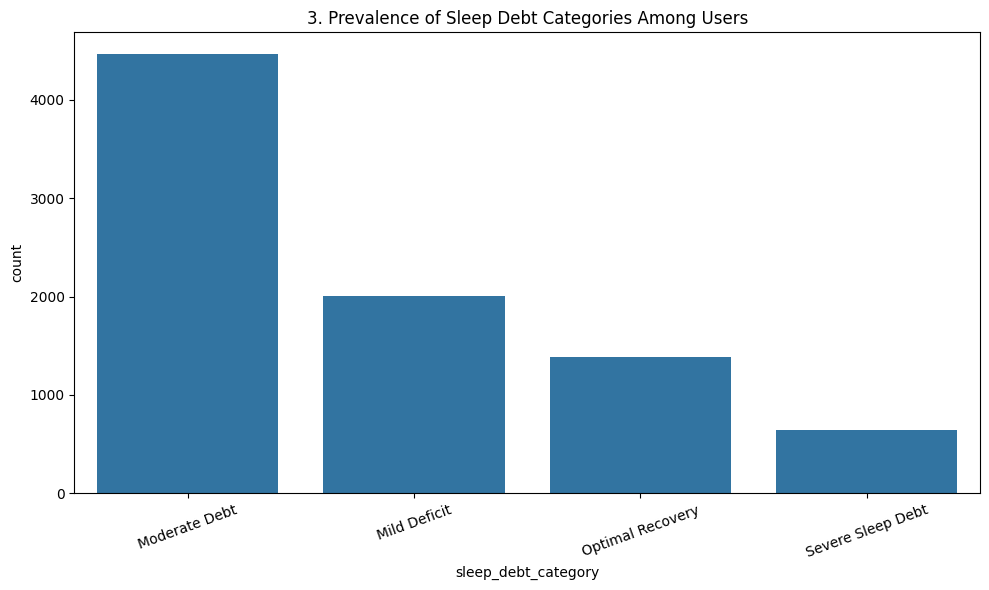

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='sleep_debt_category', order=df['sleep_debt_category'].value_counts().index)
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Prevalence of Sleep Debt Categories Among Users')
show_fig()
plot_no += 1

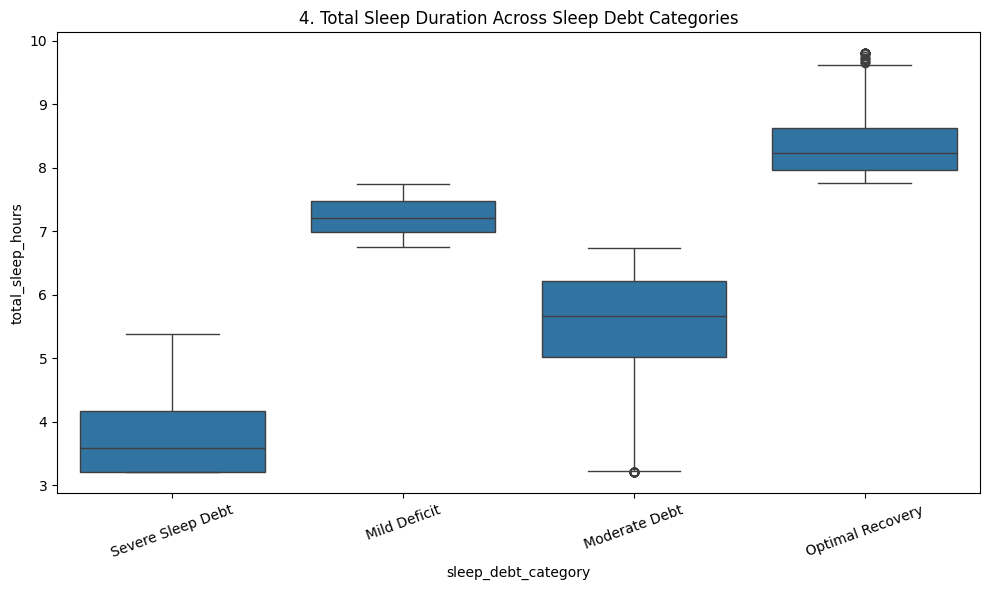

In [32]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='sleep_debt_category', y='total_sleep_hours')
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Total Sleep Duration Across Sleep Debt Categories')
show_fig()
plot_no += 1

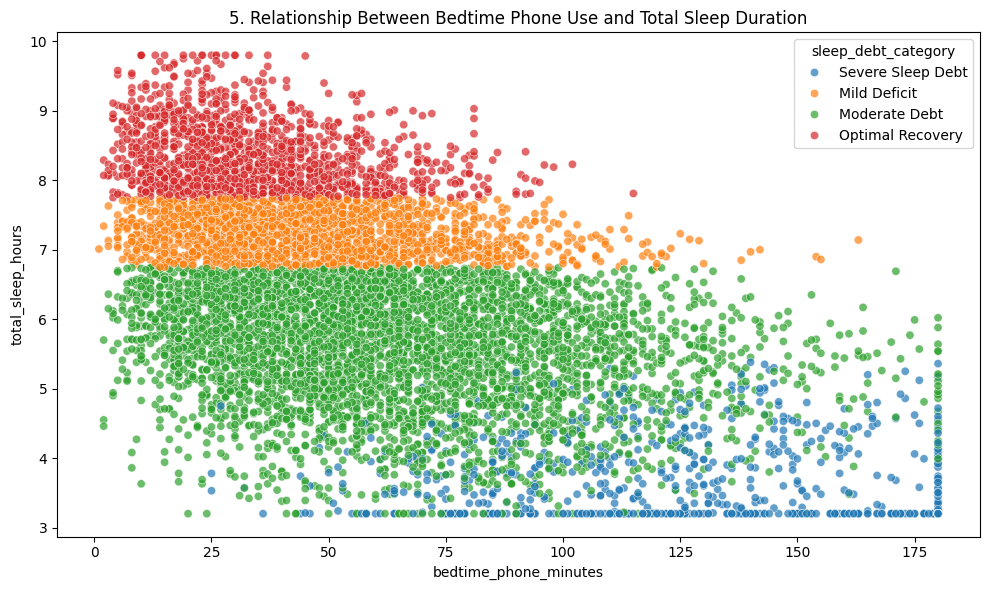

In [33]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='bedtime_phone_minutes', y='total_sleep_hours', hue='sleep_debt_category', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Bedtime Phone Use and Total Sleep Duration')
show_fig()
plot_no += 1

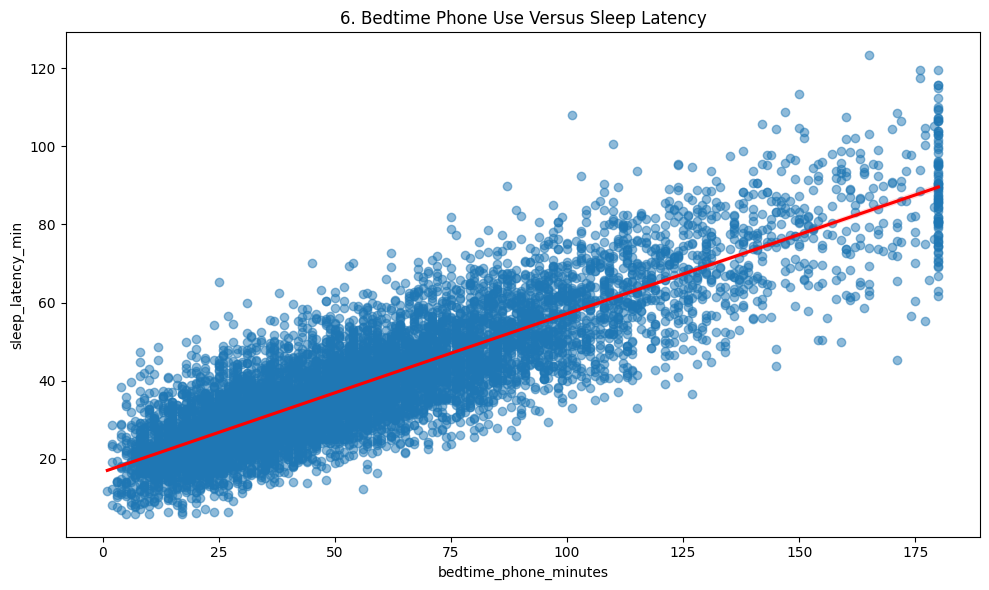

In [34]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='bedtime_phone_minutes', y='sleep_latency_min', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'{plot_no}. Bedtime Phone Use Versus Sleep Latency')
show_fig()
plot_no += 1

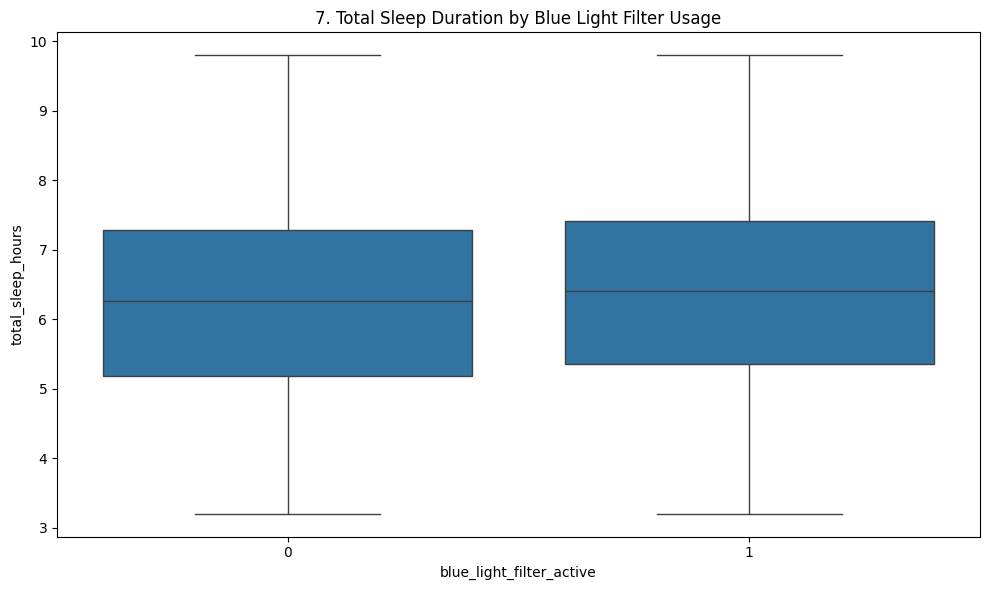

In [35]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='blue_light_filter_active', y='total_sleep_hours')
plt.title(f'{plot_no}. Total Sleep Duration by Blue Light Filter Usage')
show_fig()
plot_no += 1

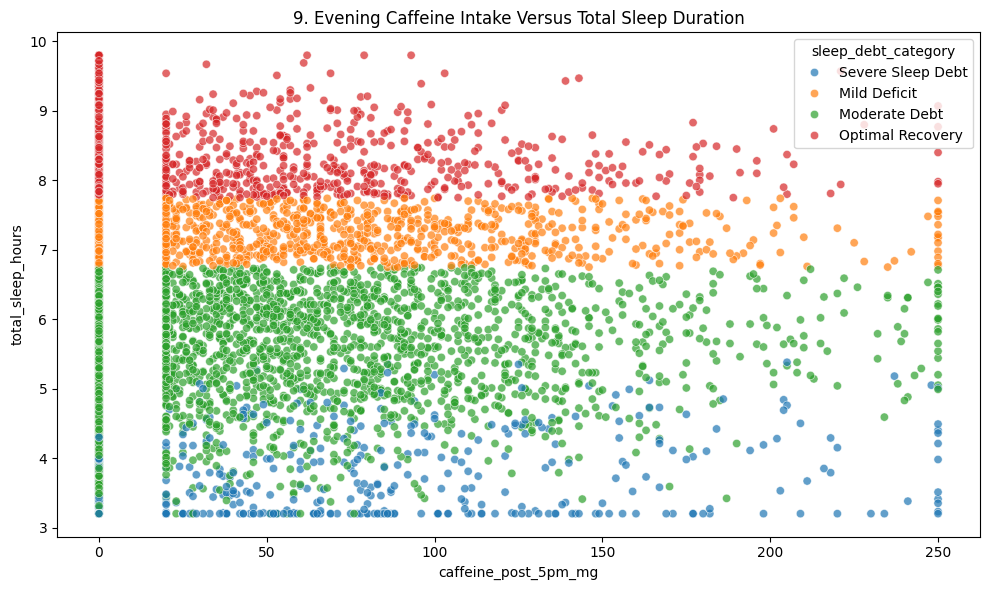

In [37]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='caffeine_post_5pm_mg', y='total_sleep_hours', hue='sleep_debt_category', alpha=0.7)
plt.title(f'{plot_no}. Evening Caffeine Intake Versus Total Sleep Duration')
show_fig()
plot_no += 1

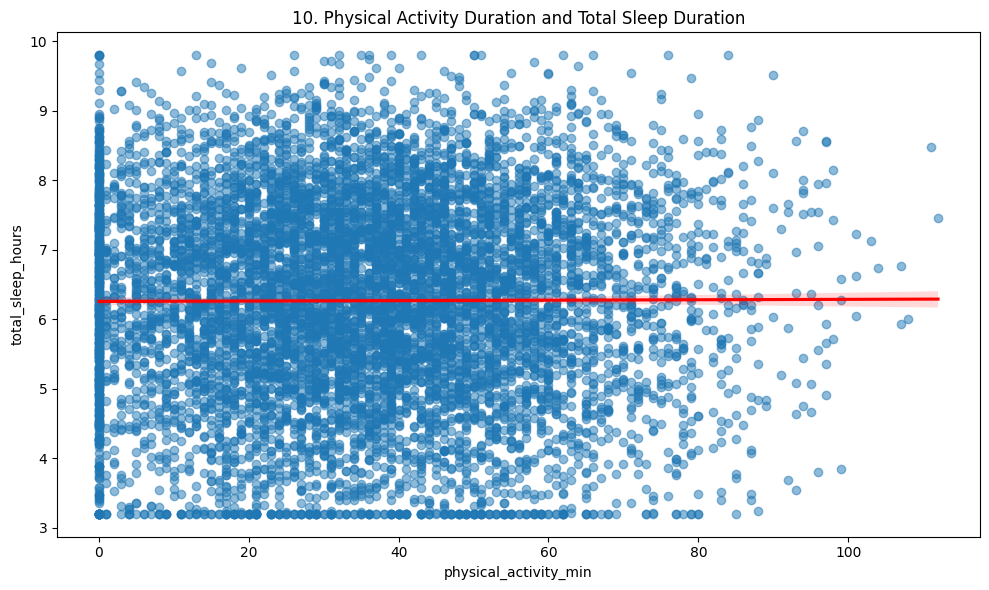

In [38]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='physical_activity_min', y='total_sleep_hours', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'{plot_no}. Physical Activity Duration and Total Sleep Duration')
show_fig()
plot_no += 1

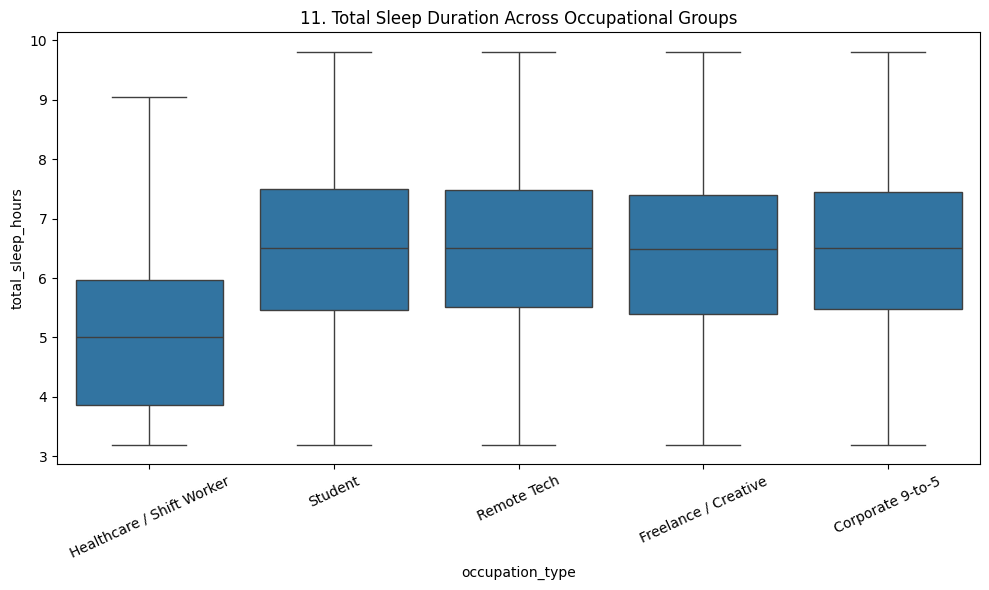

In [39]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='occupation_type', y='total_sleep_hours')
plt.xticks(rotation=25)
plt.title(f'{plot_no}. Total Sleep Duration Across Occupational Groups')
show_fig()
plot_no += 1

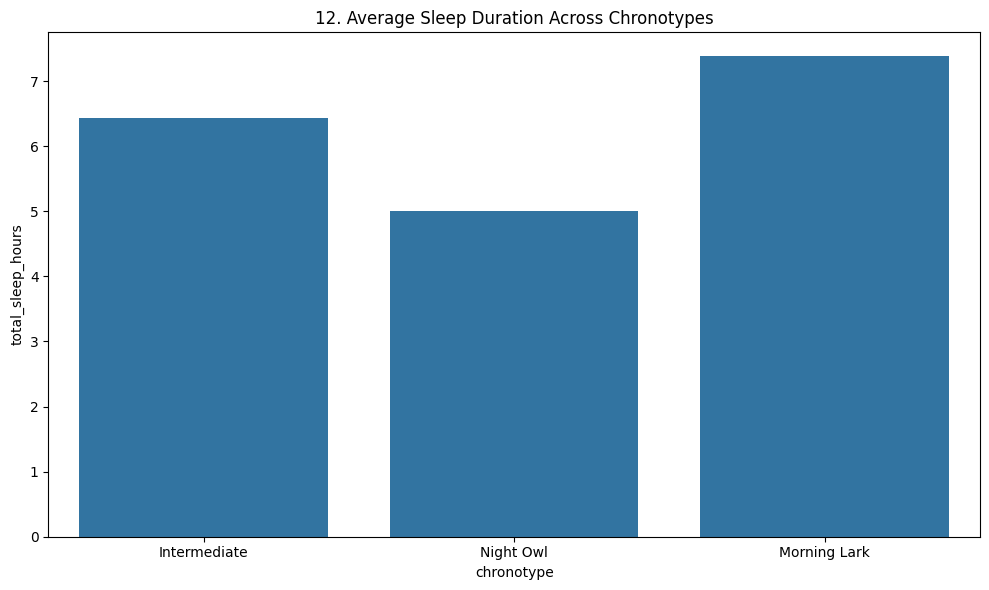

In [40]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='chronotype', y='total_sleep_hours', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Sleep Duration Across Chronotypes')
show_fig()
plot_no += 1

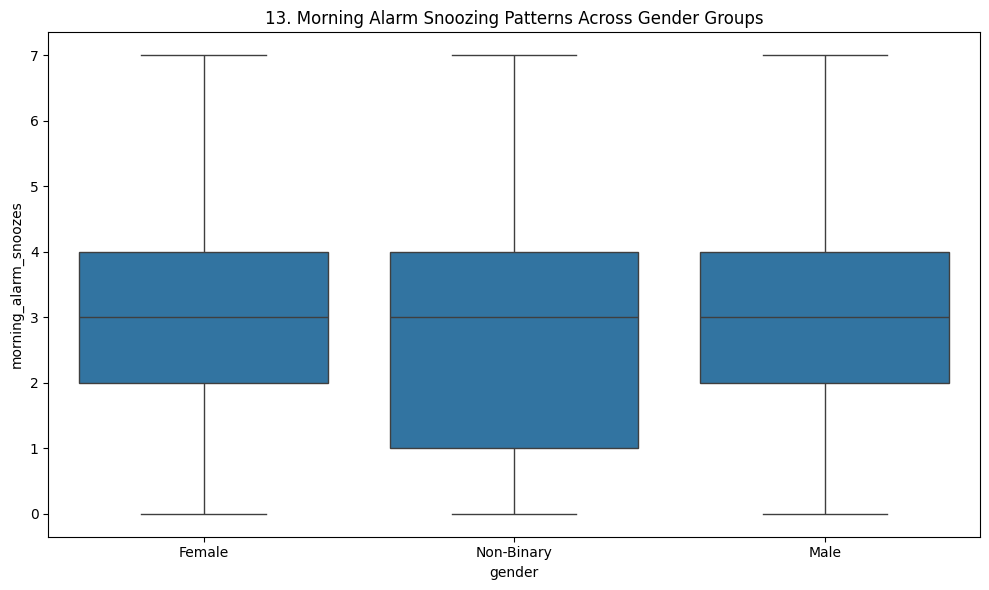

In [41]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='morning_alarm_snoozes')
plt.title(f'{plot_no}. Morning Alarm Snoozing Patterns Across Gender Groups')
show_fig()
plot_no += 1

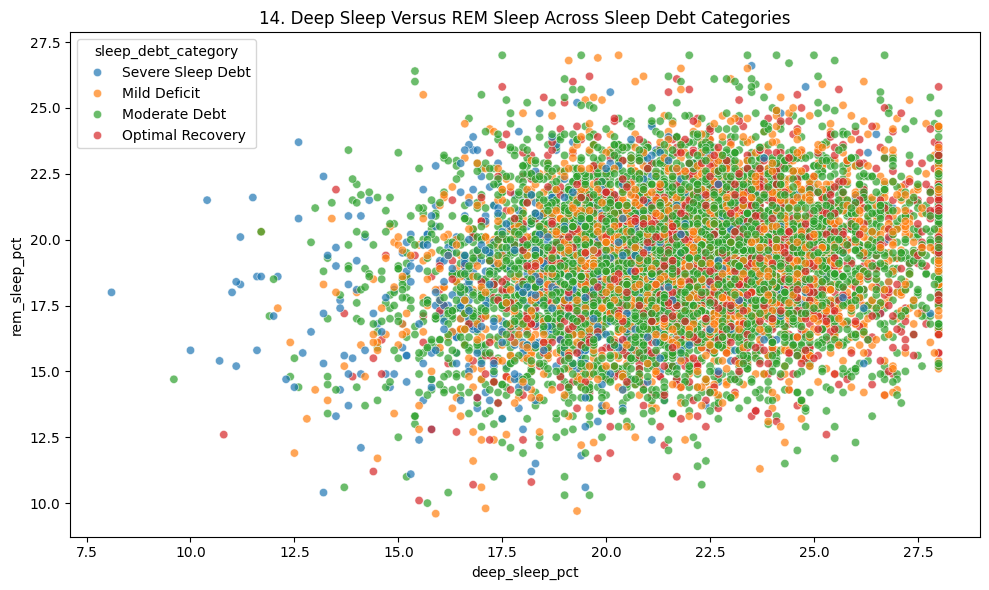

In [42]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='deep_sleep_pct', y='rem_sleep_pct', hue='sleep_debt_category', alpha=0.7)
plt.title(f'{plot_no}. Deep Sleep Versus REM Sleep Across Sleep Debt Categories')
show_fig()
plot_no += 1

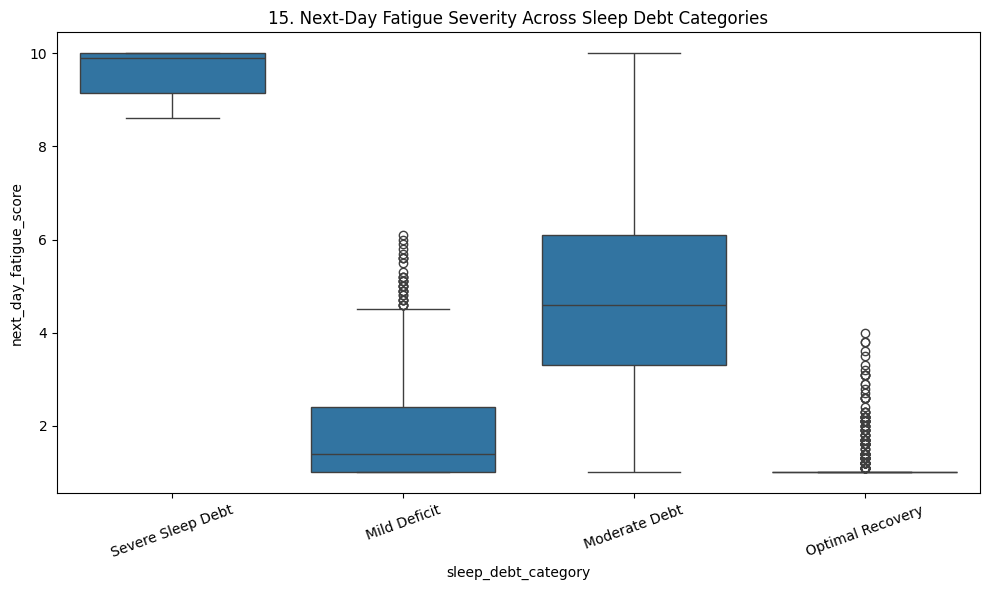

In [43]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='sleep_debt_category', y='next_day_fatigue_score')
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Next-Day Fatigue Severity Across Sleep Debt Categories')
show_fig()
plot_no += 1

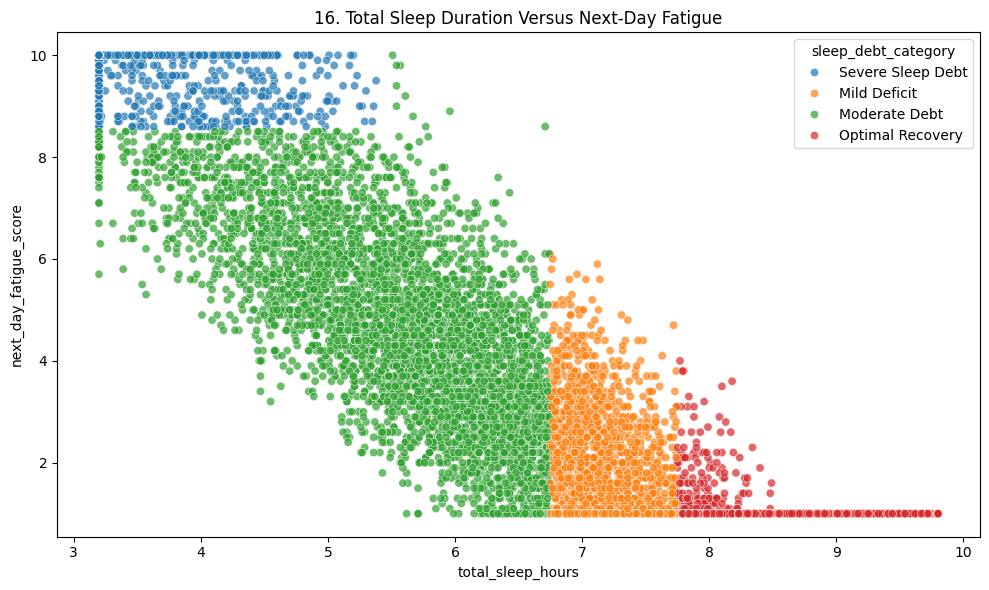

In [44]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_sleep_hours', y='next_day_fatigue_score', hue='sleep_debt_category', alpha=0.7)
plt.title(f'{plot_no}. Total Sleep Duration Versus Next-Day Fatigue')
show_fig()
plot_no += 1

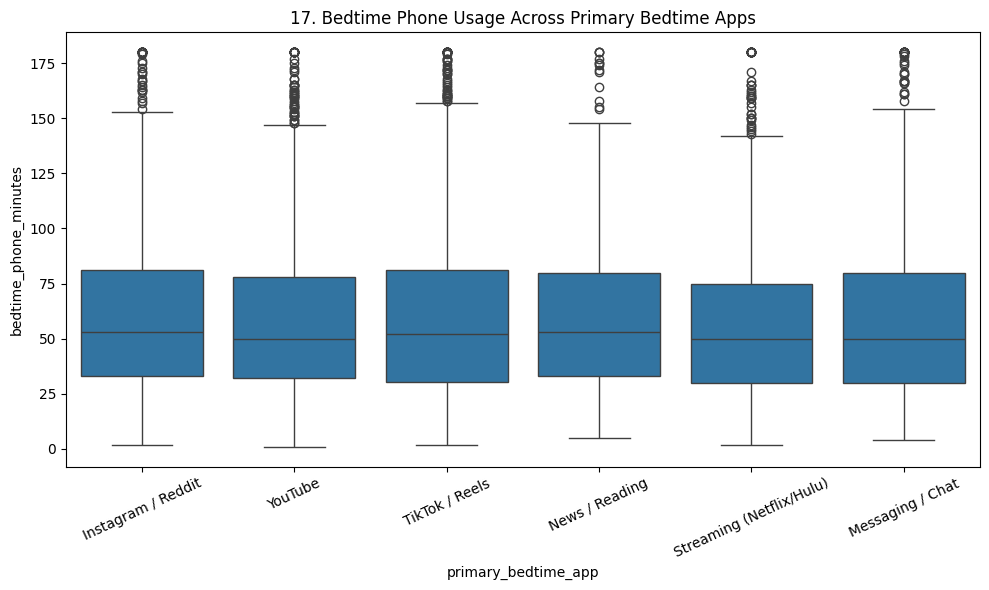

In [45]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='primary_bedtime_app', y='bedtime_phone_minutes')
plt.xticks(rotation=25)
plt.title(f'{plot_no}. Bedtime Phone Usage Across Primary Bedtime Apps')
show_fig()
plot_no += 1

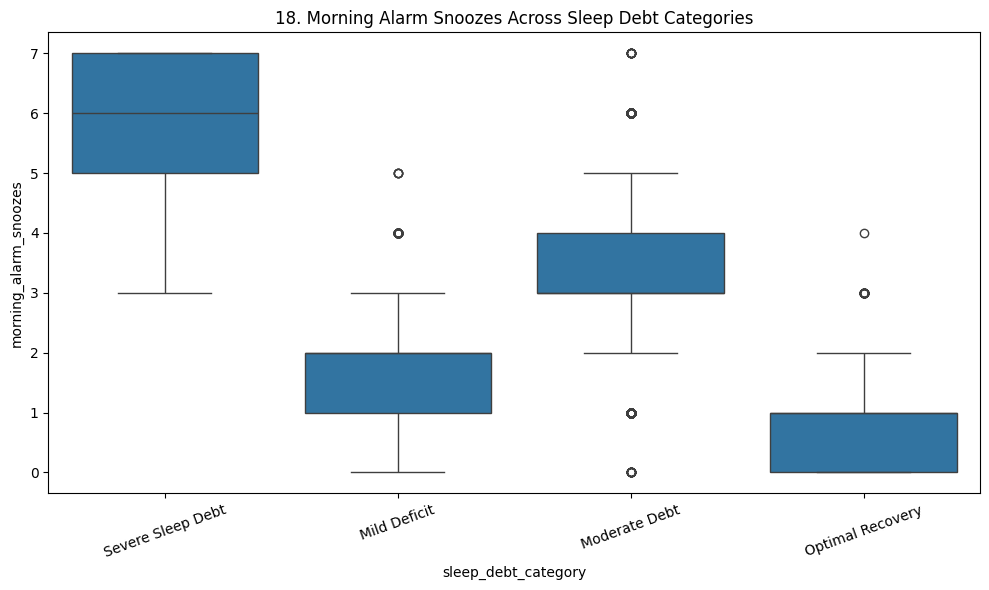

In [46]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='sleep_debt_category', y='morning_alarm_snoozes')
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Morning Alarm Snoozes Across Sleep Debt Categories')
show_fig()
plot_no += 1

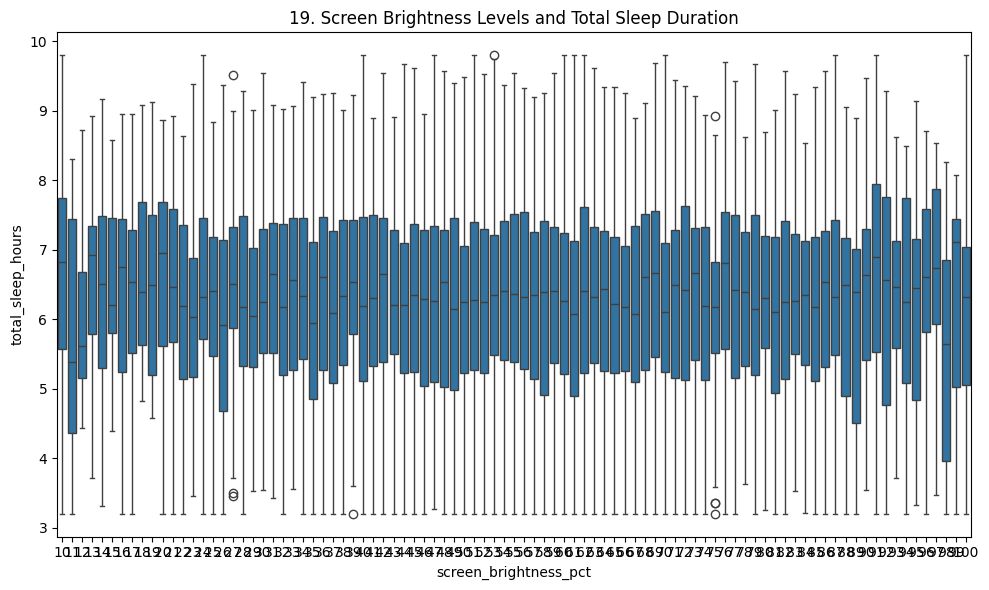

In [47]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='screen_brightness_pct', y='total_sleep_hours')
plt.title(f'{plot_no}. Screen Brightness Levels and Total Sleep Duration')
show_fig()
plot_no += 1

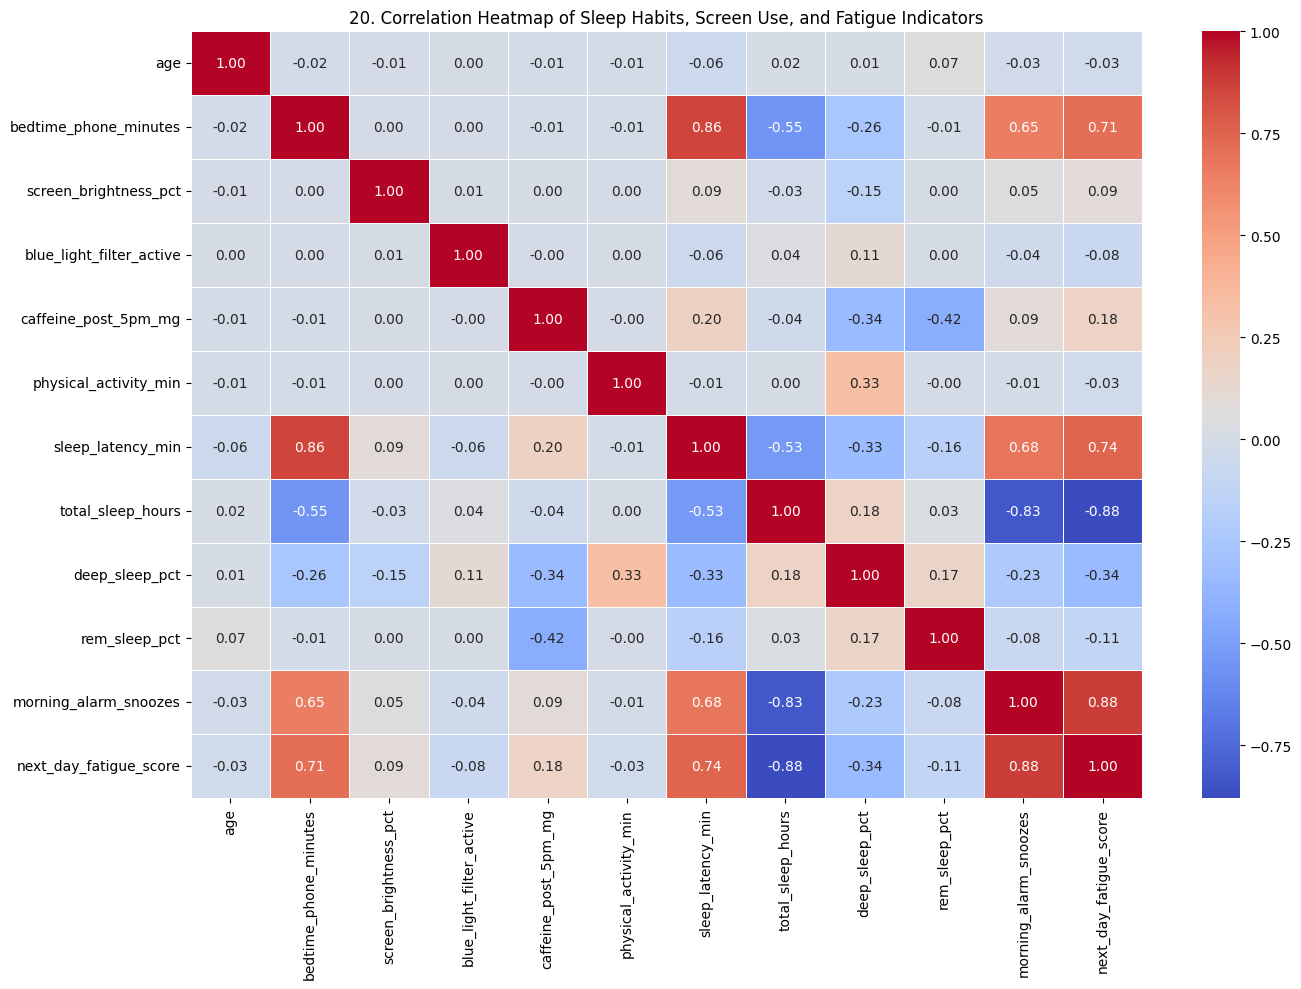

In [48]:
fig = plt.figure(figsize=(14,10))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Sleep Habits, Screen Use, and Fatigue Indicators')
show_fig()
plot_no += 1

# Model Training

## prepare features and target

In [49]:
X = df.drop(columns=['sleep_debt_category', 'user_id'])
y = df['sleep_debt_category']

X = pd.get_dummies(X, drop_first=True)

## split the dataset

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## build the classification model

In [51]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=2000))
])

## train the model

In [52]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=2000))])

## make predictions

In [53]:
y_pred = model.predict(X_test)

## calculate accuracy

In [54]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9812


## display confusion matrix

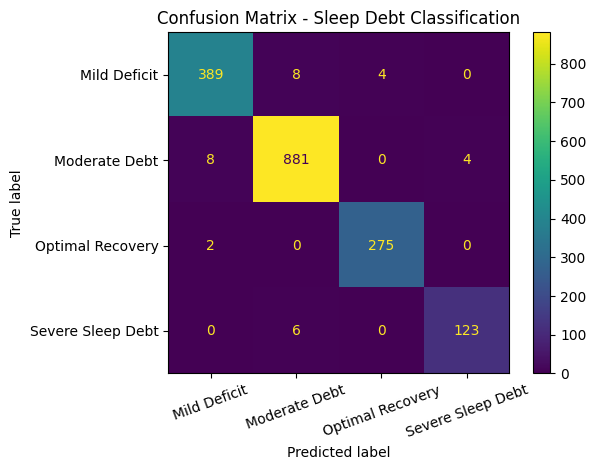

In [55]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=20)
plt.title('Confusion Matrix - Sleep Debt Classification')
show_fig()
plot_no += 1